In [1]:
import importlib
import helper
importlib.reload(helper)

<module 'helper' from '/Users/ronakpanchal/Desktop/College/ML/lab/Project/model training/helper.py'>

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report
from helper import plot_confusion_matrix, plot_roc_curve, plot_feature_importance

import shap
import lime

In [5]:
data = pd.read_csv('/Users/ronakpanchal/Desktop/College/ML/lab/Project/datasets/heart_preprocessed_scaled.csv')

In [6]:
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
catboost_clf = CatBoostClassifier(random_state=42, verbose=0)
catboost_score = cross_val_score(catboost_clf, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Catboost CV ROC-AUC Scores: {catboost_score.mean()}")
catboost_clf.fit(X_train, y_train)

Catboost CV ROC-AUC Scores: 0.9037816478921924


In [7]:
catboost_pred = catboost_clf.predict(X_test)

In [8]:
print(classification_report(y_test, catboost_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



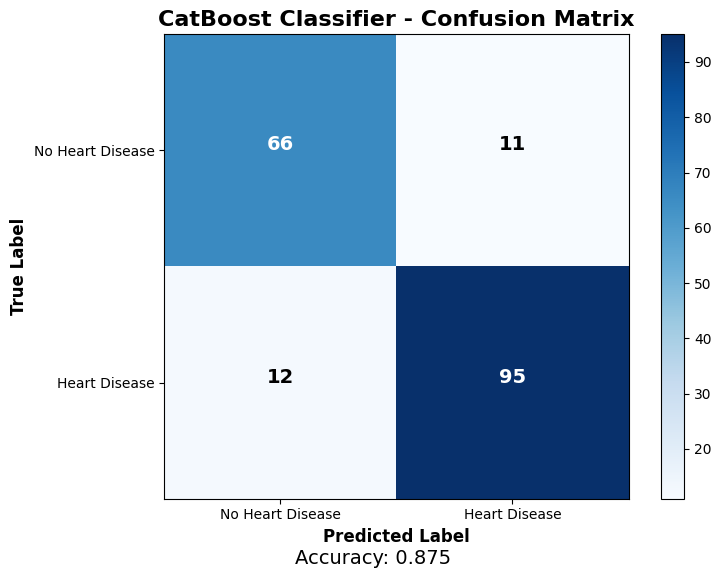


CatBoost Classifier Performance:
True Negatives: 66
False Positives: 11
False Negatives: 12
True Positives: 95
Accuracy: 0.875
Precision: 0.896
Recall: 0.888
F1-Score: 0.892


In [9]:
catboost_cm, catboost_acc = plot_confusion_matrix(y_test, catboost_pred, 'CatBoost Classifier')

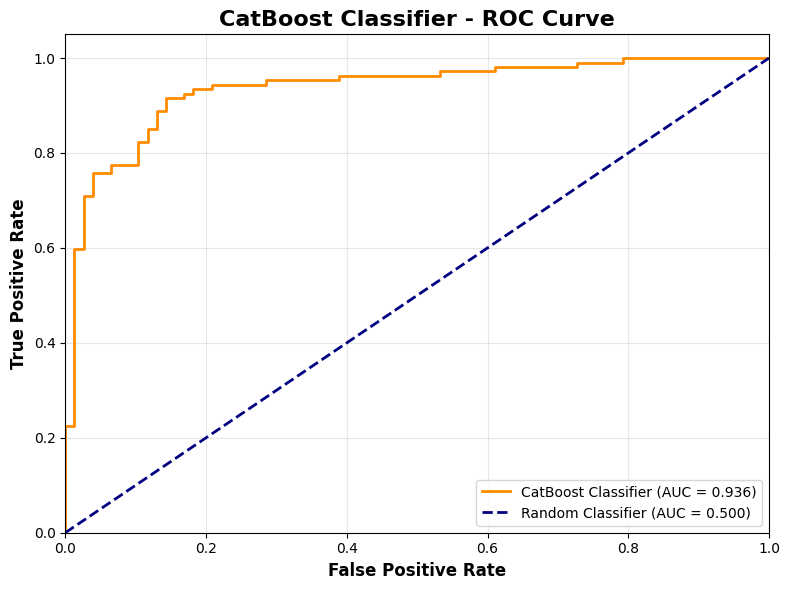


CatBoost Classifier ROC AUC Score: 0.936
Excellent performance!


In [10]:
catboost_proba = catboost_clf.predict_proba(X_test)[:,1]
catboost_fpr, catboost_tpr, catboost_threshold = plot_roc_curve(y_test, catboost_proba, "CatBoost Classifier")

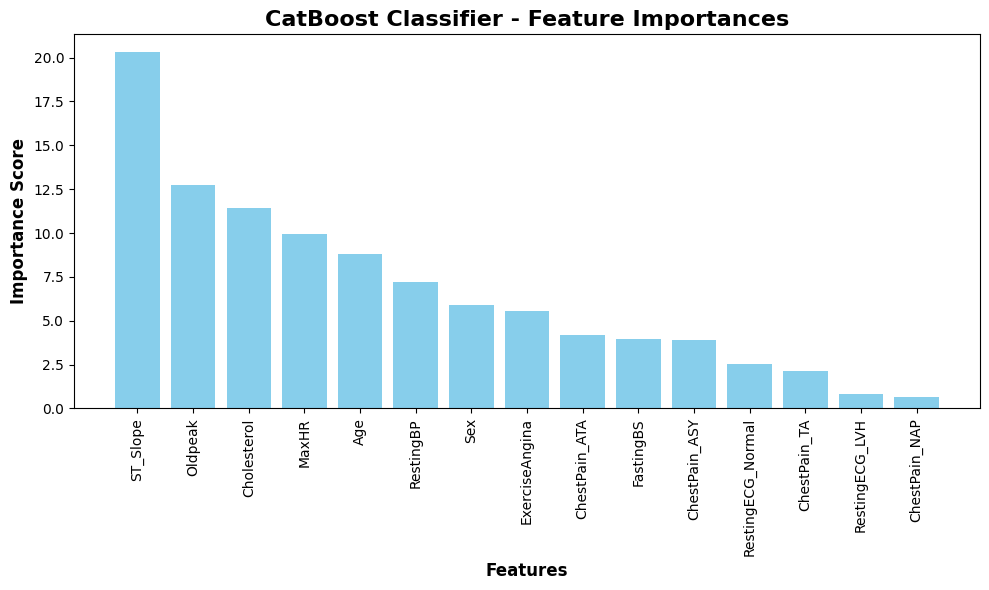


CatBoost Classifier Feature Importances:
ST_Slope: 20.3117
Oldpeak: 12.7463
Cholesterol: 11.4055
MaxHR: 9.9669
Age: 8.7981
RestingBP: 7.1840
Sex: 5.8760
ExerciseAngina: 5.5755
ChestPain_ATA: 4.1672
FastingBS: 3.9321
ChestPain_ASY: 3.8840
RestingECG_Normal: 2.5601
ChestPain_TA: 2.1170
RestingECG_LVH: 0.7999
ChestPain_NAP: 0.6758


In [11]:
plot_feature_importance(catboost_clf, X.columns, "CatBoost Classifier")

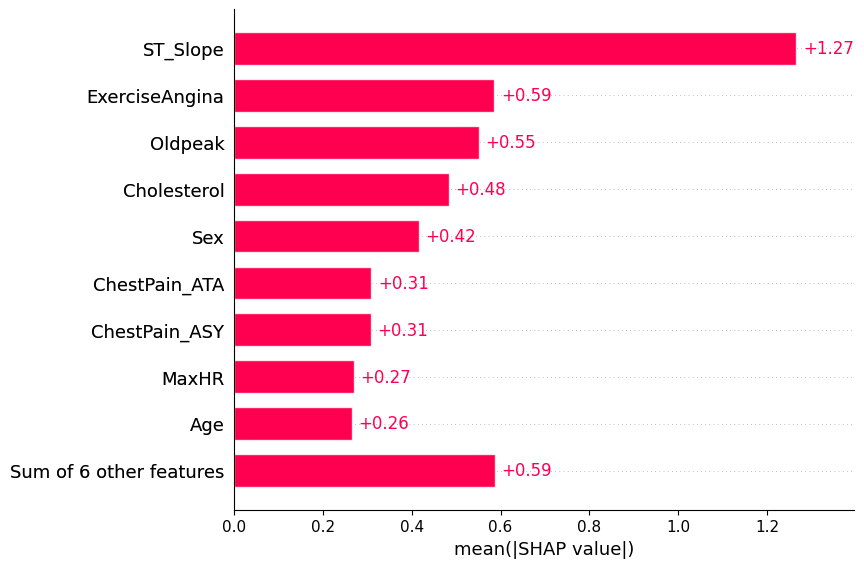

In [12]:
explainer = shap.TreeExplainer(catboost_clf)
shap_values = explainer.shap_values(X_test)

# shap_values from TreeExplainer can be a list (one array per class) or a 3D numpy array
# with shape (n_samples, n_features, n_classes). Select the positive class (index 1)
# and wrap into a shap.Explanation so shap.plots.bar accepts it.
class_idx = 1

if isinstance(shap_values, list):
	values = shap_values[class_idx]
elif hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
	values = shap_values[..., class_idx]
else:
	# fallback: assume shap_values already in the desired 2D shape
	values = shap_values

base_values = explainer.expected_value[class_idx] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value

shap_exp = shap.Explanation(values=values, base_values=base_values, data=X_test, feature_names=X_test.columns)
shap.plots.bar(shap_exp)

In [13]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(training_data=X_train.values, feature_names=X_train.columns, class_names=['No Heart Disease', 'Heart Disease'], mode='classification')
i = 180
exp = lime_explainer.explain_instance(data_row=X_test.values[i], predict_fn=catboost_clf.predict_proba)
exp.show_in_notebook(show_table=True)